In [3]:
import pandas as pd

 Student Performance Data Analysis

 Overview

This project analyzes student performance data using Python, Pandas, and Matplotlib.

The analysis explores:
- Final grade distribution
- Study time and final performance
- Absence patterns
- The relationship between previous and final grades

## Dataset

The dataset contains 395 student records and 33 variables.

The data was obtained from the UCI Machine Learning Repository's Student Performance dataset.

## Tools

- Python
- Pandas
- Matplotlib
- Jupyter Notebook

## Key Findings

### 1. Final Grade Performance
The average final grade in the dataset was 10.42 out of 20, with scores ranging from 0 to 20.

### 2. Study Time
Students in study-time category 3 had the highest average final grade at 11.40. Category 4 followed closely at 11.26, so the data does not show a simple pattern where increasing study time always leads to higher grades.

### 3. Absences
The grouped absence analysis did not show a clear linear relationship between absence frequency and final grades.

### 4. Previous and Final Grades
The strongest relationship identified was between the second-period grade (G2) and final grade (G3), with a correlation of 0.9049. This indicates a very strong positive relationship between the two variables.

## Conclusion

This analysis shows that previous academic performance has a much stronger relationship with final performance than the simple study-time and absence measures examined in this project. The findings demonstrate how data analysis can be used to identify patterns and communicate insights from real-world educational data.

In [4]:
df = pd.read_csv("data/student-mat.csv", sep=";")

## 1. Data Loading and Initial Exploration

First, we import Pandas and load the student performance dataset.

We then inspect the dataset to understand its size, columns, data types, and whether any values are missing.

In [5]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [21]:
df.shape

(395, 34)

In [22]:
df["G3"].describe()

count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64

In [7]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [9]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [10]:
df[["G1", "G2", "G3"]].describe()


,G1,G2,G3
count,395.000000,395.000000,395.000000
mean,10.908861,10.713924,10.415190
std,3.319195,3.761505,4.581443
min,3.000000,0.000000,0.000000
25%,8.000000,9.000000,8.000000
50%,11.000000,11.000000,11.000000
75%,13.000000,13.000000,14.000000
max,19.000000,19.000000,20.000000


In [11]:
df.groupby("studytime")["G3"].mean()

studytime
1    10.047619
2    10.171717
3    11.400000
4    11.259259
Name: G3, dtype: float64

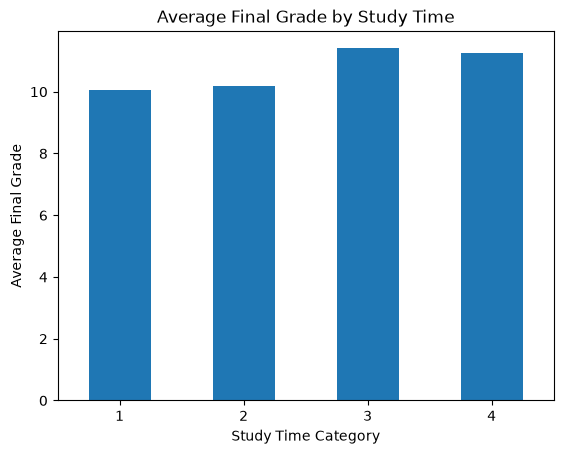

In [12]:
import matplotlib.pyplot as plt

studytime_avg = df.groupby("studytime")["G3"].mean()

studytime_avg.plot(kind="bar")

plt.title("Average Final Grade by Study Time")
plt.xlabel("Study Time Category")
plt.ylabel("Average Final Grade")
plt.xticks(rotation=0)
plt.show()

In [14]:
df.groupby("absences")["G3"].mean().head(15)


absences
0      8.443478
1     13.000000
2     11.907692
3     11.500000
4     11.283019
5     11.600000
6     11.774194
7     11.857143
8     10.590909
9     13.333333
10    11.235294
11    11.666667
12    10.750000
13    12.666667
14     9.333333
Name: G3, dtype: float64

In [16]:
df["absence_group"] = pd.cut(
    df["absences"],
    bins=[-1, 5, 10, 20, 100],
    labels=["0–5", "6–10", "11–20", "21+"]
)

df.groupby("absence_group", observed=True)["G3"].mean()

absence_group
0–5      10.168675
6–10     11.400000
11–20    10.117647
21+      10.266667
Name: G3, dtype: float64

In [17]:
df[["G2", "G3"]].corr()

,G2,G3
G2,1.000000,0.904868
G3,0.904868,1.000000


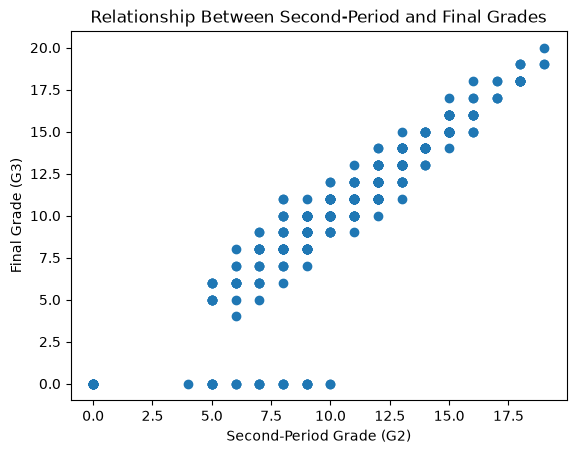

In [18]:
plt.scatter(df["G2"], df["G3"])

plt.title("Relationship Between Second-Period and Final Grades")
plt.xlabel("Second-Period Grade (G2)")
plt.ylabel("Final Grade (G3)")
plt.show()

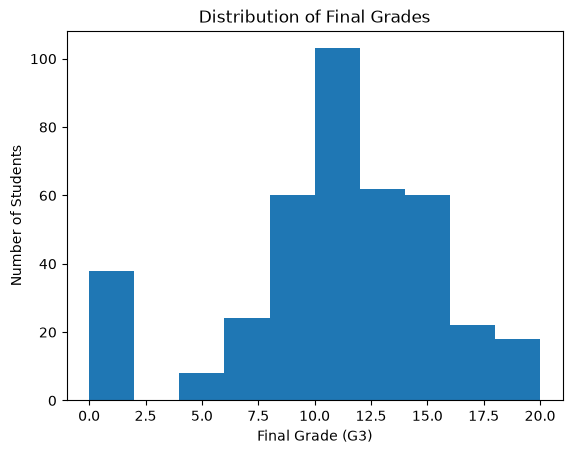

In [19]:
plt.hist(df["G3"], bins=10)

plt.title("Distribution of Final Grades")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")
plt.show()

## Dataset Source

This project uses the Student Performance dataset from the UCI Machine Learning Repository.

The dataset contains student records and academic, demographic, and social attributes used to explore factors associated with student performance.

Source: UCI Machine Learning Repository — Student Performance